# Bayesian-Inspired Rolling Regression

A rolling regression tracks time-varying exposure and acts as a lightweight fallback for Bayesian dynamic regression.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bayesian_utils import ensure_output_dir, simulate_strategy_returns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()
from bayesian_utils import rolling_regression


In [2]:
returns = simulate_strategy_returns(periods=1_260, seed=404)
rolling = rolling_regression(y=returns['momentum'], x=returns['market'], window=126)
rolling.to_parquet(OUTPUT / 'rolling_regression.parquet')
rolling.tail()

,alpha,beta,residual_vol
date,,,
2026-05-04,-0.0012,0.8823,0.0110
2026-05-05,-0.0013,0.9108,0.0111
2026-05-06,-0.0013,0.9161,0.0111
2026-05-07,-0.0013,0.9251,0.0111
2026-05-08,-0.0013,0.9213,0.0111


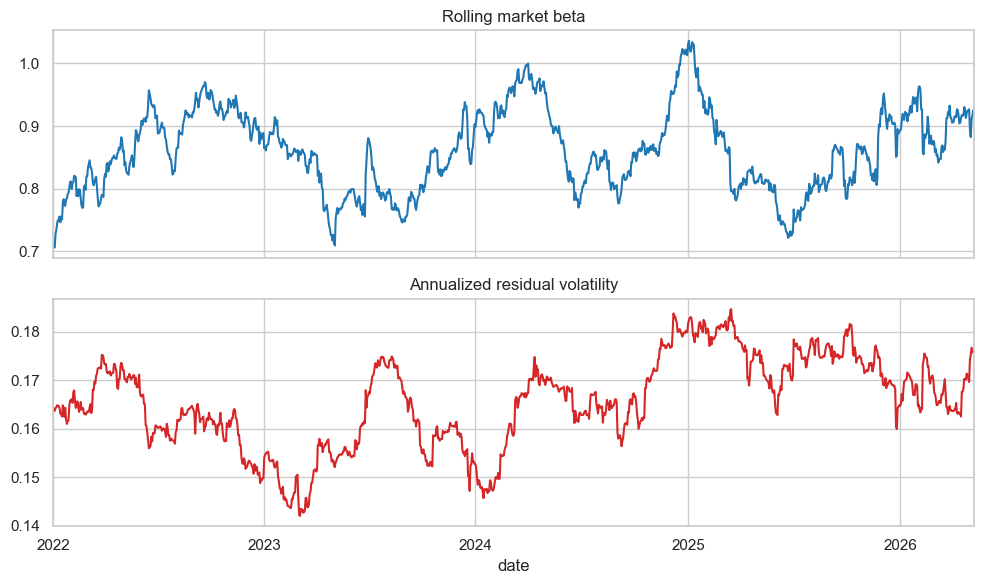

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
rolling['beta'].plot(ax=axes[0], color='tab:blue', title='Rolling market beta')
rolling['residual_vol'].mul(252**0.5).plot(ax=axes[1], color='tab:red', title='Annualized residual volatility')
plt.tight_layout()